# Zajęcie 6. System ekspertowy

## Reprezentacja reguł

In [1]:
rules = [
    {
        "if": lambda p: p["systolic_bp"] >= 140 and p["diastolic_bp"] >= 90,
        "then": "Hypertension",
        "weight": 0.9
    },
    {
        "if": lambda p: p["bmi"] >= 30,
        "then": "Obesity",
        "weight": 0.8
    },
    {
        "if": lambda p: p["glucose"] >= 126,
        "then": "Diabetes",
        "weight": 0.85
    },
    {
        "if": lambda p: p["age"] >= 65 and p["systolic_bp"] >= 140,
        "then": "High cardiovascular risk",
        "weight": 0.7
    }
]

## Mechanizm wnioskowania

In [2]:
def expert_system(patient, rules):
    conclusions = {}

    for rule in rules:
        if rule["if"](patient):
            diagnosis = rule["then"]
            weight = rule["weight"]
            conclusions[diagnosis] = max(
                conclusions.get(diagnosis, 0), weight
            )

    return conclusions

## Przykład użycia

In [3]:
patient = {
    "age": 68,
    "bmi": 31.2,
    "systolic_bp": 155,
    "diastolic_bp": 95,
    "glucose": 110
}

results = expert_system(patient, rules)

for diagnosis, confidence in results.items():
    print(f"{diagnosis}: confidence={confidence}")

Hypertension: confidence=0.9
Obesity: confidence=0.8
High cardiovascular risk: confidence=0.7


# Reguły rozmyte

In [4]:
import numpy as np

def trimf(x, a, b, c):
    """Triangular membership function."""
    x = np.asarray(x)
    y = np.zeros_like(x, dtype=float)
    # rising edge
    idx = (a < x) & (x < b)
    y[idx] = (x[idx] - a) / (b - a)
    # peak
    y[x == b] = 1.0
    # falling edge
    idx = (b < x) & (x < c)
    y[idx] = (c - x[idx]) / (c - b)
    return np.clip(y, 0, 1)

def trapmf(x, a, b, c, d):
    """Trapezoidal membership function."""
    x = np.asarray(x)
    y = np.zeros_like(x, dtype=float)
    # rising
    idx = (a < x) & (x < b)
    y[idx] = (x[idx] - a) / (b - a)
    # top
    idx = (b <= x) & (x <= c)
    y[idx] = 1.0
    # falling
    idx = (c < x) & (x < d)
    y[idx] = (d - x[idx]) / (d - c)
    return np.clip(y, 0, 1)


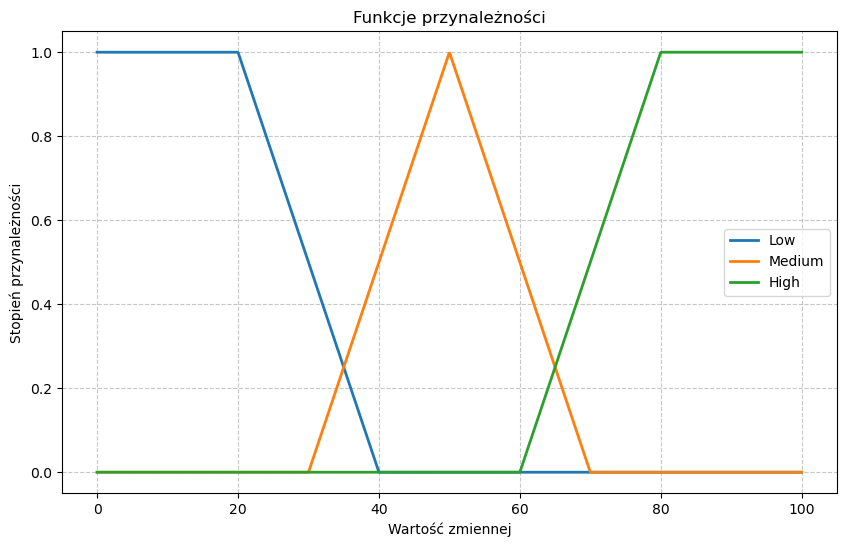

In [6]:
import matplotlib.pyplot as plt

# Zakres osi X
x = np.linspace(0, 100, 1000)

# Definicje przykładowych zbiorów rozmytych
low = trapmf(x, 0, 0, 20, 40)
medium = trimf(x, 30, 50, 70)
high = trapmf(x, 60, 80, 100, 100)

# Rysowanie wykresu
plt.figure(figsize=(10, 6))

plt.plot(x, low, label='Low', linewidth=2)
plt.plot(x, medium, label='Medium', linewidth=2)
plt.plot(x, high, label='High', linewidth=2)

plt.title('Funkcje przynależności')
plt.xlabel('Wartość zmiennej')
plt.ylabel('Stopień przynależności')
plt.ylim(-0.05, 1.05)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

## Zbiory rozmyte dla wejść i wyjść

In [5]:
# Uniwersa (zakresy) dla zmiennych
SBP = np.linspace(80, 200, 121)    # 80..200
DBP = np.linspace(40, 120, 81)     # 40..120
AGE = np.linspace(18, 90, 73)      # 18..90
RISK = np.linspace(0, 100, 101)    # 0..100

# Funkcje przynależności SBP
def sbp_low(x):    return trapmf([x], 80, 80, 110, 125)[0]
def sbp_high(x):   return trapmf([x], 135, 145, 200, 200)[0]
def sbp_border(x): return trimf([x], 120, 135, 150)[0]

# Funkcje przynależności DBP
def dbp_low(x):    return trapmf([x], 40, 40, 75, 85)[0]
def dbp_high(x):   return trapmf([x], 85, 90, 120, 120)[0]
def dbp_border(x): return trimf([x], 80, 88, 96)[0]

# Wiek
def age_young(x):  return trapmf([x], 18, 18, 30, 40)[0]
def age_old(x):    return trapmf([x], 55, 65, 90, 90)[0]
def age_mid(x):    return trimf([x], 35, 50, 65)[0]

# Wyjście: risk (zbiory rozmyte)
risk_low    = trimf(RISK, 0, 20, 40)
risk_medium = trimf(RISK, 30, 50, 70)
risk_high   = trimf(RISK, 60, 80, 100)


## Reguły rozmyte (Mamdani): min–max + centroid

In [6]:
def mamdani_infer(patient):
    sbp = patient["systolic_bp"]
    dbp = patient["diastolic_bp"]
    age = patient["age"]

    # Stopnie przynależności wejść
    mu_sbp_low = sbp_low(sbp)
    mu_sbp_bor = sbp_border(sbp)
    mu_sbp_hi  = sbp_high(sbp)

    mu_dbp_low = dbp_low(dbp)
    mu_dbp_bor = dbp_border(dbp)
    mu_dbp_hi  = dbp_high(dbp)

    mu_age_old = age_old(age)

    # --- Reguła 1: SBP high OR DBP high -> risk high
    r1 = max(mu_sbp_hi, mu_dbp_hi)

    # --- Reguła 2: SBP border AND DBP border -> risk medium
    r2 = min(mu_sbp_bor, mu_dbp_bor)

    # --- Reguła 3: SBP low AND DBP low -> risk low
    r3 = min(mu_sbp_low, mu_dbp_low)

    # --- Reguła 4: age old AND (SBP border OR DBP border) -> risk high
    r4 = min(mu_age_old, max(mu_sbp_bor, mu_dbp_bor))

    # Implication: przycinanie zbiorów wyjściowych
    out_low    = np.minimum(r3, risk_low)
    out_medium = np.minimum(r2, risk_medium)
    out_high   = np.minimum(max(r1, r4), risk_high)

    # Agregacja: max
    aggregated = np.maximum.reduce([out_low, out_medium, out_high])

    # Defuzyfikacja: środek ciężkości (centroid)
    if aggregated.sum() == 0:
        crisp = 0.0
    else:
        crisp = (RISK * aggregated).sum() / aggregated.sum()

    debug = {
        "mu": {
            "sbp_low": mu_sbp_low, "sbp_border": mu_sbp_bor, "sbp_high": mu_sbp_hi,
            "dbp_low": mu_dbp_low, "dbp_border": mu_dbp_bor, "dbp_high": mu_dbp_hi,
            "age_old": mu_age_old
        },
        "rules": {"r1": r1, "r2": r2, "r3": r3, "r4": r4},
        "crisp_risk": crisp
    }
    return crisp, aggregated, debug


## Przykład użycia + interpretacja „co zadziałało”

In [7]:
patient = {"age": 68, "systolic_bp": 155, "diastolic_bp": 95}
crisp, agg, dbg = mamdani_infer(patient)

print("Crisp risk (0-100):", round(crisp, 2))
print("Memberships:", {k: round(v, 3) for k, v in dbg["mu"].items()})
print("Rule strengths:", {k: round(v, 3) for k, v in dbg["rules"].items()})


Crisp risk (0-100): 80.0
Memberships: {'sbp_low': 0.0, 'sbp_border': 0.0, 'sbp_high': 1.0, 'dbp_low': 0.0, 'dbp_border': 0.125, 'dbp_high': 1.0, 'age_old': 1.0}
Rule strengths: {'r1': 1.0, 'r2': 0.0, 'r3': 0.0, 'r4': 0.125}


## Szybkie mapowanie na etykietę (opcjonalnie)

In [8]:
def risk_label(crisp):
    if crisp < 35:
        return "low"
    elif crisp < 65:
        return "medium"
    return "high"

print("Risk label:", risk_label(crisp))


Risk label: high


# Rozwinięcie systemu o wyjaśnianie „dlaczego” (explainable expert system).

In [9]:
import numpy as np

# ---------- Membership functions ----------
def trimf(x, a, b, c):
    x = np.asarray(x)
    y = np.zeros_like(x, dtype=float)
    idx = (a < x) & (x < b)
    y[idx] = (x[idx] - a) / (b - a)
    y[x == b] = 1.0
    idx = (b < x) & (x < c)
    y[idx] = (c - x[idx]) / (c - b)
    return np.clip(y, 0, 1)

def trapmf(x, a, b, c, d):
    x = np.asarray(x)
    y = np.zeros_like(x, dtype=float)
    idx = (a < x) & (x < b)
    y[idx] = (x[idx] - a) / (b - a)
    idx = (b <= x) & (x <= c)
    y[idx] = 1.0
    idx = (c < x) & (x < d)
    y[idx] = (d - x[idx]) / (d - c)
    return np.clip(y, 0, 1)

# ---------- Universes ----------
RISK = np.linspace(0, 100, 101)

# Output fuzzy sets
risk_low    = trimf(RISK, 0, 20, 40)
risk_medium = trimf(RISK, 30, 50, 70)
risk_high   = trimf(RISK, 60, 80, 100)

# ---------- Input fuzzy sets (single-point helpers) ----------
def sbp_low(x):    return trapmf([x], 80, 80, 110, 125)[0]
def sbp_border(x): return trimf([x], 120, 135, 150)[0]
def sbp_high(x):   return trapmf([x], 135, 145, 200, 200)[0]

def dbp_low(x):    return trapmf([x], 40, 40, 75, 85)[0]
def dbp_border(x): return trimf([x], 80, 88, 96)[0]
def dbp_high(x):   return trapmf([x], 85, 90, 120, 120)[0]

def age_old(x):    return trapmf([x], 55, 65, 90, 90)[0]


# ---------- Explainable fuzzy rule engine ----------
def explainable_fuzzy_ht_risk(patient, explain_top_k=10):
    sbp = float(patient["systolic_bp"])
    dbp = float(patient["diastolic_bp"])
    age = float(patient["age"])

    # memberships
    mu = {
        "SBP_low": sbp_low(sbp),
        "SBP_border": sbp_border(sbp),
        "SBP_high": sbp_high(sbp),
        "DBP_low": dbp_low(dbp),
        "DBP_border": dbp_border(dbp),
        "DBP_high": dbp_high(dbp),
        "AGE_old": age_old(age),
    }

    # helper ops
    AND = min
    OR = max

    # --------- Define rules with human-readable templates ----------
    rules = [
        {
            "id": "R1",
            "text": "Jeśli SBP jest WYSOKIE LUB DBP jest WYSOKIE, to ryzyko jest WYSOKIE.",
            "strength": OR(mu["SBP_high"], mu["DBP_high"]),
            "conclusion": "risk_high",
            "out_set": risk_high,
            "why": {
                "SBP_high": mu["SBP_high"],
                "DBP_high": mu["DBP_high"],
                "operator": "OR"
            }
        },
        {
            "id": "R2",
            "text": "Jeśli SBP jest GRANICZNE I DBP jest GRANICZNE, to ryzyko jest ŚREDNIE.",
            "strength": AND(mu["SBP_border"], mu["DBP_border"]),
            "conclusion": "risk_medium",
            "out_set": risk_medium,
            "why": {
                "SBP_border": mu["SBP_border"],
                "DBP_border": mu["DBP_border"],
                "operator": "AND"
            }
        },
        {
            "id": "R3",
            "text": "Jeśli SBP jest NISKIE I DBP jest NISKIE, to ryzyko jest NISKIE.",
            "strength": AND(mu["SBP_low"], mu["DBP_low"]),
            "conclusion": "risk_low",
            "out_set": risk_low,
            "why": {
                "SBP_low": mu["SBP_low"],
                "DBP_low": mu["DBP_low"],
                "operator": "AND"
            }
        },
        {
            "id": "R4",
            "text": "Jeśli wiek jest STARY I (SBP jest GRANICZNE LUB DBP jest GRANICZNE), to ryzyko jest WYSOKIE.",
            "strength": AND(mu["AGE_old"], OR(mu["SBP_border"], mu["DBP_border"])),
            "conclusion": "risk_high",
            "out_set": risk_high,
            "why": {
                "AGE_old": mu["AGE_old"],
                "SBP_border": mu["SBP_border"],
                "DBP_border": mu["DBP_border"],
                "operator": "AGE_old AND (SBP_border OR DBP_border)"
            }
        }
    ]

    # --------- Implication (clipping) + aggregation ----------
    clipped = []
    for r in rules:
        clipped_set = np.minimum(r["strength"], r["out_set"])
        clipped.append(clipped_set)
        r["clipped_area"] = float(clipped_set.sum())  # proxy "how much it contributed"

    aggregated = np.maximum.reduce(clipped) if clipped else np.zeros_like(RISK)

    # Defuzzification (centroid)
    if aggregated.sum() == 0:
        crisp = 0.0
    else:
        crisp = float((RISK * aggregated).sum() / aggregated.sum())

    # Additional interpretable metrics:
    # how much each rule contributed in area terms (normalized)
    total_area = sum(r["clipped_area"] for r in rules) + 1e-12
    for r in rules:
        r["contribution_pct"] = 100.0 * r["clipped_area"] / total_area

    # Sort rules by strength, then by contribution
    rules_sorted = sorted(rules, key=lambda r: (r["strength"], r["clipped_area"]), reverse=True)[:explain_top_k]

    # map to label
    label = "low" if crisp < 35 else ("medium" if crisp < 65 else "high")

    explanation = {
        "patient": {"age": age, "systolic_bp": sbp, "diastolic_bp": dbp},
        "memberships": mu,
        "rules_fired": rules_sorted,
        "risk_crisp": crisp,
        "risk_label": label
    }
    return explanation


def print_explanation(exp, decimals=3):
    print("=== Explainable Fuzzy Expert System (HT Risk) ===")
    p = exp["patient"]
    print(f"Pacjent: age={p['age']:.0f}, SBP={p['systolic_bp']:.0f}, DBP={p['diastolic_bp']:.0f}")
    print(f"Wynik ryzyka: {exp['risk_crisp']:.2f} / 100  ->  etykieta: {exp['risk_label']}")
    print("\nStopnie przynależności (0..1):")
    for k, v in exp["memberships"].items():
        print(f"  - {k}: {v:.{decimals}f}")

    print("\nNajbardziej aktywne reguły (dlaczego?):")
    for r in exp["rules_fired"]:
        print(f"\n[{r['id']}] {r['text']}")
        print(f"  Siła reguły (strength): {r['strength']:.{decimals}f}")
        print(f"  Udział w agregacji (proxy): {r['contribution_pct']:.1f}%")
        # show WHY details
        why = r["why"]
        if r["id"] == "R1":
            print(f"  Ponieważ: SBP_high={why['SBP_high']:.{decimals}f}, DBP_high={why['DBP_high']:.{decimals}f} (OR)")
        elif r["id"] == "R2":
            print(f"  Ponieważ: SBP_border={why['SBP_border']:.{decimals}f}, DBP_border={why['DBP_border']:.{decimals}f} (AND)")
        elif r["id"] == "R3":
            print(f"  Ponieważ: SBP_low={why['SBP_low']:.{decimals}f}, DBP_low={why['DBP_low']:.{decimals}f} (AND)")
        elif r["id"] == "R4":
            print(f"  Ponieważ: AGE_old={why['AGE_old']:.{decimals}f}, SBP_border={why['SBP_border']:.{decimals}f}, DBP_border={why['DBP_border']:.{decimals}f}")



## Użycie na przykładzie + „dlaczego?”

In [10]:
patient = {"age": 68, "systolic_bp": 155, "diastolic_bp": 95}
exp = explainable_fuzzy_ht_risk(patient)
print_explanation(exp)


=== Explainable Fuzzy Expert System (HT Risk) ===
Pacjent: age=68, SBP=155, DBP=95
Wynik ryzyka: 80.00 / 100  ->  etykieta: high

Stopnie przynależności (0..1):
  - SBP_low: 0.000
  - SBP_border: 0.000
  - SBP_high: 1.000
  - DBP_low: 0.000
  - DBP_border: 0.125
  - DBP_high: 1.000
  - AGE_old: 1.000

Najbardziej aktywne reguły (dlaczego?):

[R1] Jeśli SBP jest WYSOKIE LUB DBP jest WYSOKIE, to ryzyko jest WYSOKIE.
  Siła reguły (strength): 1.000
  Udział w agregacji (proxy): 81.1%
  Ponieważ: SBP_high=1.000, DBP_high=1.000 (OR)

[R4] Jeśli wiek jest STARY I (SBP jest GRANICZNE LUB DBP jest GRANICZNE), to ryzyko jest WYSOKIE.
  Siła reguły (strength): 0.125
  Udział w agregacji (proxy): 18.9%
  Ponieważ: AGE_old=1.000, SBP_border=0.000, DBP_border=0.125

[R2] Jeśli SBP jest GRANICZNE I DBP jest GRANICZNE, to ryzyko jest ŚREDNIE.
  Siła reguły (strength): 0.000
  Udział w agregacji (proxy): 0.0%
  Ponieważ: SBP_border=0.000, DBP_border=0.125 (AND)

[R3] Jeśli SBP jest NISKIE I DBP jest N

## Opcjonalnie: zwracanie śladu rozumowania (trace) do raportu

In [11]:
def explanation_text(exp):
    lines = []
    lines.append(f"Ryzyko = {exp['risk_crisp']:.1f}/100 ({exp['risk_label']}).")
    top = exp["rules_fired"][0]
    lines.append(f"Najsilniejsza reguła: {top['id']} (strength={top['strength']:.2f}, wkład~{top['contribution_pct']:.0f}%).")
    lines.append(top["text"])
    return "\n".join(lines)

print(explanation_text(exp))


Ryzyko = 80.0/100 (high).
Najsilniejsza reguła: R1 (strength=1.00, wkład~81%).
Jeśli SBP jest WYSOKIE LUB DBP jest WYSOKIE, to ryzyko jest WYSOKIE.
